# 05 momentdetr_cross.ipynb — Cross-Encoder Saliency

Полный pipeline: кодирование видео → query-conditioned saliency scores → group_segments → оценка.

Для запуска выполни ячейки сверху вниз.

## 0. Скачивание чекпоинта (выполнить один раз)

Чекпоинт уже распакован в `notebooks/checkpoints/cgdetr_clip_qvhighlights.ckpt`.

Если нужно повторить скачивание:

```bash
# Скачать архив (44.7 GB, все модели lighthouse)
gdown "1jxs_bvwttXTF9Lk3aKLohkqfYOonLyrO" -O /tmp/lighthouse_weights.zip

# Извлечь только нужный чекпоинт (~137 MB)
cd notebooks/checkpoints
unzip /tmp/lighthouse_weights.zip "results/cg_detr/qvhighlight/clip/best.ckpt"
mv results/cg_detr/qvhighlight/clip/best.ckpt cgdetr_clip_qvhighlights.ckpt
rm -rf results
rm /tmp/lighthouse_weights.zip
```

## 1. Импорты

In [1]:
import sys
sys.path.insert(0, '.')

import torch
torch.cuda.set_device(2)
_ = torch.zeros(1, device='cuda:2')

# PyTorch 2.6 changed weights_only default to True; lighthouse checkpoint uses easydict
_orig_torch_load = torch.load
def _patched_torch_load(f, *args, **kwargs):
    kwargs.setdefault('weights_only', False)
    return _orig_torch_load(f, *args, **kwargs)
torch.load = _patched_torch_load

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from pathlib import Path
from decord import VideoReader, cpu

import config
from utils.download import load_annotations
from lighthouse.models import CGDETRPredictor
from utils.search import group_segments
from utils.metrics import compute_metrics, per_query_stats, iou_with_windows, KS

## 2. Настройка

In [2]:
# ── Модель ────────────────────────────────────────────────────
CGDETR_CKPT   = str(config.CGDETR_CKPT)
CGDETR_DEVICE = config.CGDETR_DEVICE

# ── Поиск ─────────────────────────────────────────────────────
SEARCH_K = config.SEARCH_K
GAP_SEC  = config.GAP_WINDOW_SEC

# ── Производные ───────────────────────────────────────────────
INDEX_TYPE = "cgdetr_saliency"
FEATS_DIR  = config.FEATS_CGDETR_DIR

config.RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FEATS_DIR.mkdir(parents=True, exist_ok=True)

print(f"CGDETR_CKPT  : {CGDETR_CKPT}")
print(f"FEATS_DIR    : {FEATS_DIR}")
print(f"RESULTS_DIR  : {config.RESULTS_DIR}")

CGDETR_CKPT  : /home/vadim.akhmetov/work/natural-language-video-search/notebooks/checkpoints/cgdetr_clip_qvhighlights.ckpt
FEATS_DIR    : /home/vadim.akhmetov/work/natural-language-video-search/notebooks/data/qvhighlights/feats_cgdetr
RESULTS_DIR  : /home/vadim.akhmetov/work/natural-language-video-search/notebooks/data/qvhighlights/results


## 3. Загрузка модели

In [3]:
model = CGDETRPredictor(CGDETR_CKPT, device=CGDETR_DEVICE, feature_name='clip')
print(f"CGDETRPredictor loaded on {CGDETR_DEVICE}")

CGDETRPredictor loaded on cuda:2


## 4. Кодирование видео

Использует shared cache из `feats_cgdetr/` (созданный notebook 04).
Дополнительно запоминает длительность каждого видео для маппинга saliency → временны́е метки.

In [4]:
vid_to_split: dict[str, str] = {}
for split in config.SPLITS:
    path = config.ANNOTATIONS_DIR / f"{split}_downloaded.jsonl"
    if path.exists():
        for item in load_annotations(path):
            vid_to_split[item["vid"]] = split

video_paths = sorted(config.VIDEO_DIR.glob("*.mp4"))
print(f"Videos: {len(video_paths)}")

Videos: 105


In [5]:
def _feats_to_device(feats: dict, device: str) -> dict:
    return {k: v.to(device) if isinstance(v, torch.Tensor) else v for k, v in feats.items()}

video_feats:     dict[str, object] = {}
video_durations: dict[str, float]  = {}

for video_path in tqdm(video_paths, desc="Encoding"):
    vid_id = video_path.stem

    vr = VideoReader(str(video_path), ctx=cpu(0))
    video_durations[vid_id] = len(vr) / vr.get_avg_fps()

    cache_path = FEATS_DIR / f"{vid_id}.pt"
    if cache_path.exists():
        feats = torch.load(str(cache_path), map_location="cpu", weights_only=False)
        video_feats[vid_id] = _feats_to_device(feats, CGDETR_DEVICE)
    else:
        feats = model.encode_video(str(video_path))
        torch.save({k: v.cpu() if isinstance(v, torch.Tensor) else v for k, v in feats.items()}, str(cache_path))
        video_feats[vid_id] = _feats_to_device(feats, CGDETR_DEVICE)

print(f"Encoded {len(video_feats)} videos")

Encoding: 100%|██████████| 105/105 [00:03<00:00, 34.09it/s]

Encoded 105 videos


## 5. Поиск

Для каждого запроса: `predict` → `pred_saliency_scores` → per-frame хиты →
`group_segments` склеивает соседние кадры с высоким score.

In [6]:
annotations = []
for split in config.SPLITS:
    path = config.ANNOTATIONS_DIR / f"{split}_downloaded.jsonl"
    if path.exists():
        annotations.extend(load_annotations(path))
print(f"Queries: {len(annotations)}")

Queries: 107


In [7]:
rows = []

for ann in tqdm(annotations, desc="Search"):
    qid        = ann["qid"]
    query      = ann["query"]
    gt_vid     = ann["vid"]
    gt_windows = str(ann["relevant_windows"])

    all_hits = []
    for vid_id, feats in video_feats.items():
        pred     = model.predict(query, feats)
        saliency = pred.get("pred_saliency_scores", [])
        n        = len(saliency)
        if n == 0:
            continue
        duration = video_durations[vid_id]
        clip_dur = duration / n

        for i, score in enumerate(saliency):
            start_sec = i * clip_dur
            end_sec   = (i + 1) * clip_dur
            all_hits.append({
                "video_id":      vid_id,
                "start_sec":     start_sec,
                "end_sec":       end_sec,
                "timestamp_sec": (start_sec + end_sec) / 2.0,
                "score":         float(score),
            })

    hits_df = (
        pd.DataFrame(all_hits)
        .sort_values("score", ascending=False)
        .head(SEARCH_K)
    )
    segs = group_segments(hits_df, gap_sec=GAP_SEC)

    for rank, (_, seg) in enumerate(segs.iterrows(), start=1):
        rows.append({
            "qid":        qid,
            "query":      query,
            "gt_vid":     gt_vid,
            "gt_windows": gt_windows,
            "index_type": INDEX_TYPE,
            "rank":       rank,
            "pred_vid":   seg["video_id"],
            "pred_start": seg["start_sec"],
            "pred_end":   seg["end_sec"],
            "score":      seg["score"],
        })

results = pd.DataFrame(rows)
print(f"Total rows: {len(results):,}")

out_path = config.RESULTS_DIR / "search_results_saliency.parquet"
results.to_parquet(out_path, index=False)
print(f"Saved → {out_path}")

Search: 100%|██████████| 107/107 [04:55<00:00,  2.76s/it]

Total rows: 905
Saved → /home/vadim.akhmetov/work/natural-language-video-search/notebooks/data/qvhighlights/results/search_results_saliency.parquet


## 6. Оценка

Метрики качества поиска + разбор полётов.

In [8]:
if "annotations" not in dir() or len(annotations) == 0:
    annotations = []
    for split in config.SPLITS:
        path = config.ANNOTATIONS_DIR / f"{split}_downloaded.jsonl"
        if path.exists():
            annotations.extend(load_annotations(path))

if "results" not in dir():
    results = pd.read_parquet(config.RESULTS_DIR / "search_results_saliency.parquet")

print(f"Results: {len(results):,} rows")
print(f"Queries: {results['qid'].nunique()}")
print(f"Index types: {results['index_type'].unique().tolist()}")

Results: 905 rows
Queries: 107
Index types: ['cgdetr_saliency']


### Сводная таблица метрик

In [9]:
all_types = results["index_type"].unique().tolist()
metrics_by_type = {}
for idx_type in all_types:
    subset = results[results["index_type"] == idx_type]
    metrics_by_type[idx_type] = compute_metrics(subset, annotations)

summary = pd.DataFrame(metrics_by_type).T
summary.index.name = "index_type"
print(summary.to_string(float_format=lambda x: f"{x:.3f}"))

                 video_recall@1  video_recall@2  video_recall@3  video_recall@5  video_recall@10  video_recall@15  video_recall@20  video_precision@1  video_precision@2  video_precision@3  video_precision@5  video_precision@10  video_precision@15  video_precision@20  ndcg@1  ndcg@2  ndcg@3  ndcg@5  ndcg@10  ndcg@15  ndcg@20  video_f1@1  video_f1@2  video_f1@3  video_f1@5  video_f1@10  video_f1@15  video_f1@20  video_mrr  video_map  mean_iou  mean_iou@top1  mean_iou@top5  hit@1@iou03  moment_mrr@iou03  moment_recall@1@iou03  moment_precision@1@iou03  moment_recall@2@iou03  moment_precision@2@iou03  moment_recall@3@iou03  moment_precision@3@iou03  moment_recall@5@iou03  moment_precision@5@iou03  moment_recall@10@iou03  moment_precision@10@iou03  moment_recall@15@iou03  moment_precision@15@iou03  moment_recall@20@iou03  moment_precision@20@iou03  hit@1@iou05  moment_mrr@iou05  moment_recall@1@iou05  moment_precision@1@iou05  moment_recall@2@iou05  moment_precision@2@iou05  moment_recall@3

### Heatmap метрик

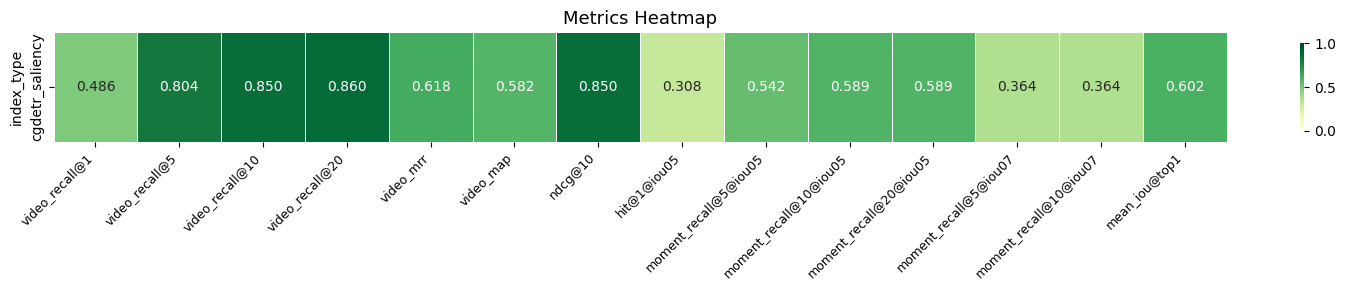

In [10]:
HEATMAP_COLS = [
    "video_recall@1", "video_recall@5", "video_recall@10", "video_recall@20",
    "video_mrr", "video_map", "ndcg@10",
    "hit@1@iou05", "moment_recall@5@iou05", "moment_recall@10@iou05", "moment_recall@20@iou05",
    "moment_recall@5@iou07", "moment_recall@10@iou07",
    "mean_iou@top1",
]
heatmap_cols = [c for c in HEATMAP_COLS if c in summary.columns]
heatmap_df = summary[heatmap_cols]

fig, ax = plt.subplots(figsize=(max(14, len(heatmap_cols) * 1.1), max(3, len(summary) * 0.9)))
sns.heatmap(
    heatmap_df.astype(float), ax=ax, annot=True, fmt=".3f",
    vmin=0, vmax=1, cmap="YlGn", linewidths=0.5, cbar_kws={"shrink": 0.8},
)
ax.set_title("Metrics Heatmap", fontsize=13)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=9)
plt.tight_layout()
plt.show()

### Recall@K кривые

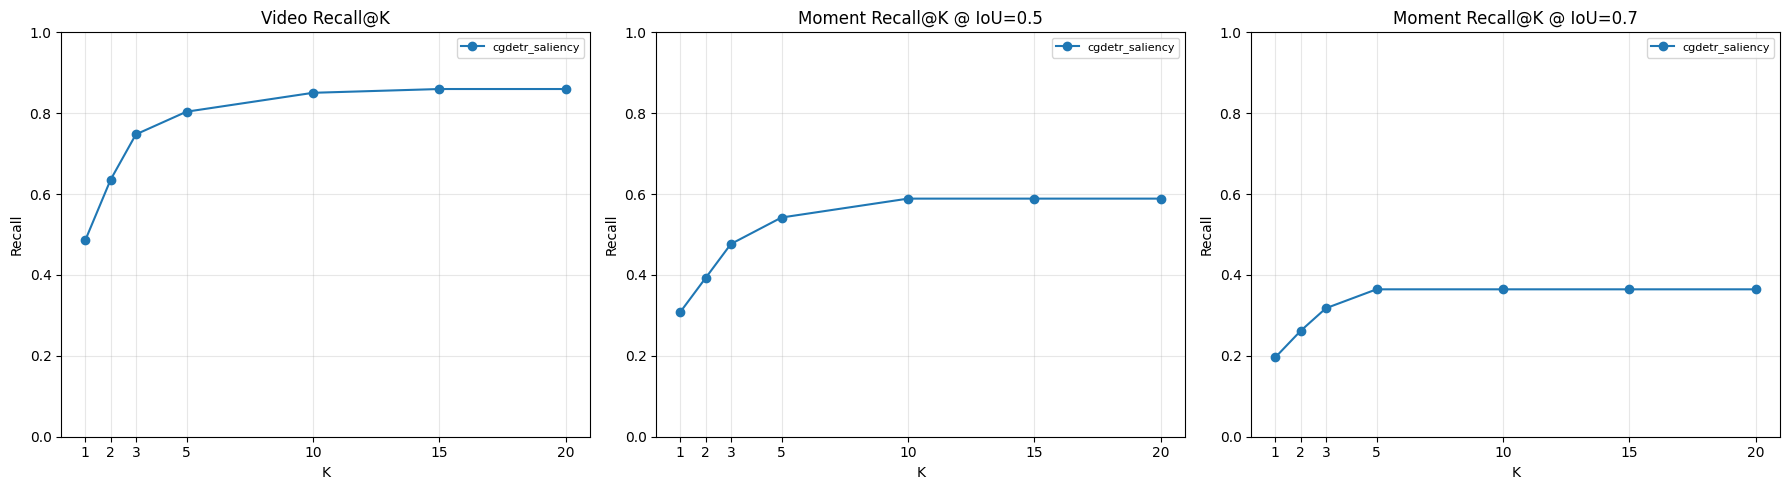

In [11]:
plots_spec = [
    ("Video Recall@K",            [f"video_recall@{k}"        for k in KS]),
    ("Moment Recall@K @ IoU=0.5", [f"moment_recall@{k}@iou05" for k in KS]),
    ("Moment Recall@K @ IoU=0.7", [f"moment_recall@{k}@iou07" for k in KS]),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (title, cols) in zip(axes, plots_spec):
    for idx_type, row in summary.iterrows():
        vals = [row.get(c, float("nan")) for c in cols]
        ax.plot(KS, vals, marker="o", label=idx_type)
    ax.set_title(title); ax.set_xlabel("K"); ax.set_ylabel("Recall")
    ax.set_ylim(0, 1); ax.set_xticks(KS); ax.grid(True, alpha=0.3); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

### Разбор полётов

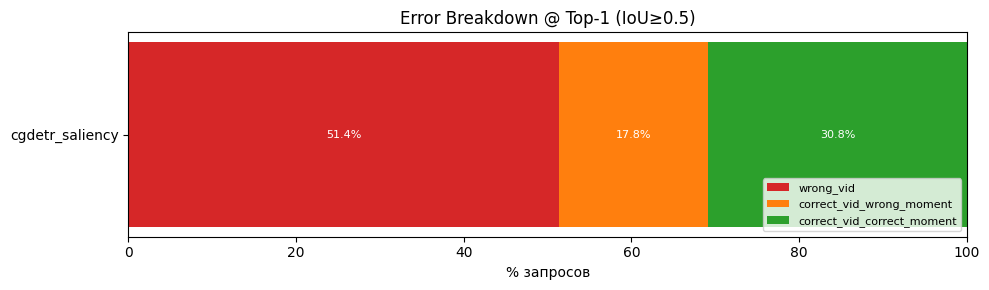


=== CGDETR_SALIENCY — Топ-5 лучших ===
                                                                                   query  first_correct_video_rank  best_iou  top1_score
                                                  Blonde woman holds up food in her car.                       1.0  0.388889   -6.967330
                                        Woman walks outside with large white sunglasses.                       1.0  0.887889   -6.228767
                    A man showing the electronic devices of a first class airplane seat.                       1.0  0.428571   -5.839727
A man drives in his car and talks as we see footage from the dash camera of a busy city.                       1.0  0.999890   -5.686849
                             A woman talks to camera about ice cream and shows some off.                       1.0  0.639929   -6.646420

=== CGDETR_SALIENCY — Топ-5 худших (из найденных) ===
                                                   query  first_correct_video_rank 

In [12]:
stats = per_query_stats(results, annotations)

_ERROR_COLORS = {
    "wrong_vid":                  "#d62728",
    "correct_vid_wrong_moment":   "#ff7f0e",
    "correct_vid_correct_moment": "#2ca02c",
}
_CATEGORIES = list(_ERROR_COLORS.keys())

error_counts = stats.groupby(["index_type", "error_class"]).size().unstack(fill_value=0)
total_per_type = stats.groupby("index_type").size()
error_pct = error_counts.div(total_per_type, axis=0) * 100
for cat in _CATEGORIES:
    if cat not in error_pct.columns:
        error_pct[cat] = 0.0
error_pct = error_pct[_CATEGORIES]

fig, ax = plt.subplots(figsize=(10, max(3, len(error_pct) * 0.9)))
left = np.zeros(len(error_pct))
for cat in _CATEGORIES:
    vals = error_pct[cat].values
    bars = ax.barh(error_pct.index, vals, left=left, color=_ERROR_COLORS[cat], label=cat)
    for bar, v in zip(bars, vals):
        if v > 3:
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_y() + bar.get_height() / 2,
                    f"{v:.1f}%", ha="center", va="center", fontsize=8, color="white")
    left += vals
ax.set_xlabel("% запросов"); ax.set_title("Error Breakdown @ Top-1 (IoU≥0.5)")
ax.legend(loc="lower right", fontsize=8); ax.set_xlim(0, 100)
plt.tight_layout(); plt.show()

cols_show = ["query", "first_correct_video_rank", "best_iou", "top1_score"]
for idx_type in results["index_type"].unique():
    grp = stats[stats["index_type"] == idx_type].sort_values("first_correct_video_rank")
    print(f"\n=== {idx_type.upper()} — Топ-5 лучших ===")
    print(grp.head(5)[cols_show].to_string(index=False))
    finite = grp[grp["first_correct_video_rank"] < float("inf")]
    print(f"\n=== {idx_type.upper()} — Топ-5 худших (из найденных) ===")
    print(finite.tail(5)[cols_show].to_string(index=False))

## 7. ClearML

Логирует эксперимент в ClearML.

In [13]:
os.environ.setdefault("CLEARML_CONFIG_FILE", "clearml.conf")

from utils.clearml_logger import log_experiment

task_name = "CG-DETR / saliency"

log_experiment(
    task_name=task_name,
    config_dict={
        k: v for k, v in vars(config).items()
        if not k.startswith("_") and not callable(v)
    },
    results_df=results,
    annotations=annotations,
    extra_params={
        "index_type": INDEX_TYPE,
        "gap_sec":    GAP_SEC,
    },
)
print(f"Logged to ClearML ✓  task_name={task_name!r}")

Logged to ClearML ✓  task_name='CG-DETR / saliency'
